In [3]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import traceback

class LicensePlateDataset(Dataset):
    """
    Custom dataset class for loading license plate data
    """
    def __init__(self, image_paths, annotations, transform=None):
        """
        Initialize dataset
        
        Args:
            image_paths: List of image paths
            annotations: List of annotation information
            transform: Image transformations
        """
        self.image_paths = image_paths
        self.annotations = annotations
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            img_path = self.image_paths[idx]
            annotation = self.annotations[idx]
            
            # Read image
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Unable to read image {img_path}")
                # Return empty image and bounding box
                dummy_image = np.zeros((300, 300, 3), dtype=np.uint8)
                image = dummy_image
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Extract bounding box information
            boxes = []
            labels = []
            
            for obj in annotation:
                xmin = obj['xmin']
                ymin = obj['ymin']
                xmax = obj['xmax']
                ymax = obj['ymax']
                
                # Ensure bounding box is valid
                if xmax <= xmin or ymax <= ymin:
                    continue
                
                # Ensure coordinates are within image bounds
                h, w = image.shape[:2]
                xmin, xmax = max(0, xmin), min(w, xmax)
                ymin, ymax = max(0, ymin), min(h, ymax)
                
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(1)  # 1 represents license plate class
            
            # Ensure at least one valid bounding box
            if len(boxes) == 0:
                # Create a small dummy bounding box
                h, w = image.shape[:2]
                boxes.append([0, 0, min(100, w), min(100, h)])
                labels.append(1)
            
            boxes = np.array(boxes, dtype=np.float32)
            labels = np.array(labels)
            
            # Apply image transformations
            if self.transform:
                try:
                    transformed = self.transform(image=image, bboxes=boxes, labels=labels)
                    image = transformed['image']
                    boxes = torch.tensor(transformed['bboxes'], dtype=torch.float32) if len(transformed['bboxes']) > 0 else torch.zeros((1, 4), dtype=torch.float32)
                    labels = torch.tensor(transformed['labels'], dtype=torch.int64) if len(transformed['labels']) > 0 else torch.ones(1, dtype=torch.int64)
                except Exception as e:
                    print(f"Transform error: {e} in image {img_path}")
                    # Return original image and bounding box
                    image = torch.from_numpy(image.transpose((2, 0, 1))).float() / 255.0
                    boxes = torch.tensor(boxes, dtype=torch.float32)
                    labels = torch.tensor(labels, dtype=torch.int64)
            else:
                image = torch.from_numpy(image.transpose((2, 0, 1))).float() / 255.0
                boxes = torch.tensor(boxes, dtype=torch.float32)
                labels = torch.tensor(labels, dtype=torch.int64)
            
            # Build target dictionary
            target = {}
            target['boxes'] = boxes
            target['labels'] = labels
            
            return image, target
        except Exception as e:
            print(f"Error loading data at index {idx}, image path: {self.image_paths[idx] if idx < len(self.image_paths) else 'unknown'}")
            print(f"Error message: {str(e)}")
            
            # Return safe fallback values
            dummy_image = torch.zeros((3, 300, 300), dtype=torch.float32)
            dummy_boxes = torch.tensor([[0, 0, 100, 100]], dtype=torch.float32)
            dummy_labels = torch.tensor([1], dtype=torch.int64)
            
            target = {}
            target['boxes'] = dummy_boxes
            target['labels'] = dummy_labels
            
            return dummy_image, target

class LicensePlateDetector:
    """
    License plate detector class
    """
    def __init__(self, dataset_path):
        """
        Initialize license plate detector
        
        Args:
            dataset_path: Dataset path
        """
        self.dataset_path = dataset_path
        self.images_dir = os.path.join(dataset_path, 'images')
        # Check if annotations directory exists, if not try using annotation
        if os.path.exists(os.path.join(dataset_path, 'annotations')):
            self.annotations_dir = os.path.join(dataset_path, 'annotations')
        else:
            self.annotations_dir = os.path.join(dataset_path, 'annotation')
        
        # Validate dataset structure
        self._validate_dataset()
        
        # Set device
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
    def _validate_dataset(self):
        """Validate dataset structure"""
        if not os.path.exists(self.images_dir):
            raise FileNotFoundError(f"Image directory not found: {self.images_dir}")
        if not os.path.exists(self.annotations_dir):
            raise FileNotFoundError(f"Annotation directory not found: {self.annotations_dir}")
    
    def get_image_paths_and_annotations(self):
        """Get all image paths and annotations"""
        extensions = ['*.jpg', '*.jpeg', '*.png']
        image_paths = []
        for ext in extensions:
            image_paths.extend(glob(os.path.join(self.images_dir, ext)))
        
        # Ensure paths are ordered for easier processing
        image_paths.sort()
        
        valid_image_paths = []
        annotations = []
        
        for img_path in image_paths:
            img_name = os.path.basename(img_path)
            base_name = os.path.splitext(img_name)[0]
            xml_path = os.path.join(self.annotations_dir, f"{base_name}.xml")
            
            if os.path.exists(xml_path):
                try:
                    # Verify image is readable
                    img = cv2.imread(img_path)
                    if img is None:
                        print(f"Warning: Unable to read image {img_path}, skipping")
                        continue
                    
                    # Parse annotation
                    annotation = self.parse_annotation(xml_path)
                    
                    # Only add valid annotations
                    if annotation:
                        valid_image_paths.append(img_path)
                        annotations.append(annotation)
                    else:
                        print(f"Warning: No valid annotations in {xml_path}")
                except Exception as e:
                    print(f"Error processing image or annotation {img_path}: {str(e)}")
            else:
                print(f"Warning: Annotation file not found for {img_name}")
        
        print(f"Found {len(valid_image_paths)} valid image-annotation pairs")
        return valid_image_paths, annotations
    
    def parse_annotation(self, xml_file):
        """
        Parse XML annotation file, extract license plate bounding boxes
        
        Args:
            xml_file: XML annotation file path
            
        Returns:
            List of license plate objects containing bounding box coordinates
        """
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            license_plates = []
            
            for obj in root.findall('object'):
                name_elem = obj.find('name')
                if name_elem is None:
                    continue
                    
                name = name_elem.text
                
                # Only look for 'licence' objects
                if name == 'licence':
                    bbox = obj.find('bndbox')
                    if bbox is None:
                        continue
                        
                    xmin_elem = bbox.find('xmin')
                    ymin_elem = bbox.find('ymin')
                    xmax_elem = bbox.find('xmax')
                    ymax_elem = bbox.find('ymax')
                    
                    if None in (xmin_elem, ymin_elem, xmax_elem, ymax_elem):
                        continue
                        
                    try:
                        xmin = int(xmin_elem.text)
                        ymin = int(ymin_elem.text)
                        xmax = int(xmax_elem.text)
                        ymax = int(ymax_elem.text)
                        
                        # Validate bounding box
                        if xmin >= xmax or ymin >= ymax:
                            print(f"Warning: Invalid bounding box found in {xml_file} ({xmin}, {ymin}, {xmax}, {ymax})")
                            continue
                        
                        license_plates.append({
                            'xmin': xmin,
                            'ymin': ymin,
                            'xmax': xmax,
                            'ymax': ymax
                        })
                    except (ValueError, TypeError) as e:
                        print(f"Warning: Error parsing bounding box values in {xml_file}: {str(e)}")
            
            return license_plates
        except Exception as e:
            print(f"Error parsing annotation file {xml_file}: {str(e)}")
            return []
    
    def get_model(self, num_classes=2):  # Background class + license plate class
        """
        Create object detection model (using pre-trained Faster R-CNN)
        
        Args:
            num_classes: Number of classes (background + license plate)
            
        Returns:
            Trained model
        """
        # Load pre-trained Faster R-CNN model
        model = models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
        
        # Modify classifier head for license plate detection task
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
        
        return model
    
    def get_transforms(self, train=True):
        """
        Get image transformations
        
        Args:
            train: Whether for training
            
        Returns:
            Albumentations transformations
        """
        if train:
            return A.Compose([
                A.Resize(height=512, width=512),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))
        else:
            return A.Compose([
                A.Resize(height=512, width=512),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))
    
    @staticmethod
    def collate_fn(batch):
        """
        Custom collate function for handling images and targets of different sizes
        """
        return tuple(zip(*batch))
    
    def bbox_iou(self, box1, box2):
        """
        Calculate IOU matrix between two sets of bounding boxes
    
        Args:
            box1: Bounding boxes of shape (N, 4)
            box2: Bounding boxes of shape (M, 4)
        
        Returns:
            IOU matrix of shape (N, M)
        """
        # Ensure inputs are correct size
        if box1.dim() == 1:
            box1 = box1.unsqueeze(0)
        if box2.dim() == 1:
            box2 = box2.unsqueeze(0)
    
        # Get number of boxes
        N = box1.size(0)
        M = box2.size(0)
    
        # Expand dimensions for broadcasting
        box1 = box1.unsqueeze(1).expand(N, M, 4)
        box2 = box2.unsqueeze(0).expand(N, M, 4)
    
        # Calculate intersection top-left and bottom-right
        lt = torch.max(box1[..., :2], box2[..., :2])
        rb = torch.min(box1[..., 2:], box2[..., 2:])
    
        # Calculate intersection width and height
        wh = (rb - lt).clamp(min=0)
    
        # Calculate intersection area
        inter = wh[..., 0] * wh[..., 1]
    
        # Calculate area of each box
        area1 = (box1[..., 2] - box1[..., 0]) * (box1[..., 3] - box1[..., 1])
        area2 = (box2[..., 2] - box2[..., 0]) * (box2[..., 3] - box2[..., 1])
    
        # Calculate union area
        union = area1 + area2 - inter
    
        # Calculate IOU
        iou = inter / (union + 1e-6)
    
        return iou
    
    def train_model(self, epochs=20, batch_size=4, learning_rate=0.001, save_path='license_plate_model.pth'):
        """
        Train license plate detection model
        
        Args:
            epochs: Number of training epochs
            batch_size: Batch size
            learning_rate: Learning rate
            save_path: Model save path
            
        Returns:
            Trained model
        """
        # Get image paths and annotations
        print("Loading dataset...")
        image_paths, annotations = self.get_image_paths_and_annotations()
        
        if len(image_paths) == 0:
            raise ValueError("No valid image and annotation data found")
        
        # Split training and validation sets
        train_img_paths, val_img_paths, train_annotations, val_annotations = train_test_split(
            image_paths, annotations, test_size=0.2, random_state=42
        )
        
        print(f"Training set: {len(train_img_paths)} images")
        print(f"Validation set: {len(val_img_paths)} images")
        
        # Create datasets and data loaders
        train_dataset = LicensePlateDataset(
            train_img_paths, 
            train_annotations, 
            transform=self.get_transforms(train=True)
        )
        
        val_dataset = LicensePlateDataset(
            val_img_paths, 
            val_annotations, 
            transform=self.get_transforms(train=False)
        )
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=self.collate_fn,
            num_workers=0,  # Set num_workers to 0 to avoid multiprocessing issues
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
            num_workers=0,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        # Create model
        model = self.get_model()
        model = model.to(self.device)
        
        # Define optimizer
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=0.0005)
        
        # Learning rate scheduler
        lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
        
        best_val_loss = float('inf')
        
        for epoch in range(epochs):
            # Training mode
            model.train()
            train_loss = 0
            
            print(f"Epoch {epoch+1}/{epochs}")
            
            # Training loop
            for i, (images, targets) in enumerate(tqdm(train_loader, desc="Training")):
                try:
                    images = list(image.to(self.device) for image in images)
                    targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                    
                    # Validate data
                    valid_batch = True
                    for target in targets:
                        if target['boxes'].numel() == 0:
                            print(f"Warning: Empty bounding box in batch {i}, skipping")
                            valid_batch = False
                            break
                    
                    if not valid_batch:
                        continue
                    
                    optimizer.zero_grad()
                    
                    # Forward pass, compute loss
                    loss_dict = model(images, targets)
                    losses = sum(loss for loss in loss_dict.values())
                    
                    # Check if loss is valid
                    if not torch.isfinite(losses):
                        print(f"Warning: Loss is infinite or NaN, skipping batch")
                        continue
                    
                    # Backward pass
                    losses.backward()
                    optimizer.step()
                    
                    train_loss += losses.item()
                    
                    # Print loss
                    if (i + 1) % 10 == 0:
                        print(f"Batch {i+1}/{len(train_loader)}, Loss: {losses.item():.4f}")
                except Exception as e:
                    print(f"Error processing batch {i}: {str(e)}")
                    continue
            
            # Update learning rate
            lr_scheduler.step()
            
            # Calculate average training loss
            train_loss /= len(train_loader)
            
            # Validation mode
            model.eval()
            val_loss = 0
            val_batches = 0
        
            with torch.no_grad():
                for i, (images, targets) in enumerate(tqdm(val_loader, desc="Validating")):
                    try:
                        images = list(image.to(self.device) for image in images)
                        targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                    
                        # Validate data
                        valid_batch = True
                        for target in targets:
                            if target['boxes'].numel() == 0:
                                valid_batch = False
                                break
                    
                        if not valid_batch:
                            continue
                    
                        # Get predictions
                        predictions = model(images)
                    
                        # Calculate validation metrics manually
                        batch_metric = 0
                        for pred, target in zip(predictions, targets):
                            # If there are prediction boxes and ground truth boxes
                            if pred['boxes'].shape[0] > 0 and target['boxes'].shape[0] > 0:
                                # Calculate max IOU as evaluation metric
                                ious = self.bbox_iou(pred['boxes'], target['boxes'])
                                max_ious, _ = ious.max(dim=1) 
                                mean_iou = max_ious.mean().item()
                                # Convert to positive loss value (1-IOU loss)
                                pred_loss = 1.0 - mean_iou
                            else:
                                # If no prediction boxes or ground truth boxes, set maximum penalty
                                pred_loss = 1.0

                            # Add this sample's loss
                            batch_metric += pred_loss
                    
                        # Calculate batch average loss
                        batch_metric /= len(images)
                        val_loss += batch_metric
                        val_batches += 1
                    
                    except Exception as e:
                        print(f"Error during validation batch {i}: {str(e)}")
                        continue
        
            # Calculate average validation loss
            if val_batches > 0:
                val_loss /= val_batches
            else:
                val_loss = 1.0  # Set to maximum loss
        
            print(f"Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")
        
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), save_path)
                print(f"Model saved to {save_path}")
    
        print("Training complete!")
        return model
    
    def predict(self, model, image_path, confidence_threshold=0.5):
        """
        Use trained model to predict license plate locations in an image
        
        Args:
            model: Trained model
            image_path: Image path
            confidence_threshold: Confidence threshold
            
        Returns:
            Original image, image with bounding boxes, license plate location list
        """
        # Load model
        if isinstance(model, str):
            loaded_model = self.get_model()
            loaded_model.load_state_dict(torch.load(model, map_location=self.device))
            model = loaded_model
        
        model.to(self.device)
        model.eval()
        
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Cannot read image: {image_path}")
            
        orig_image = image.copy()
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Save original dimensions
        original_height, original_width = image.shape[:2]
        
        # Apply transformations
        transform = A.Compose([
            A.Resize(height=512, width=512),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
        
        transformed = transform(image=image)
        image_tensor = transformed['image']
        
        # Add batch dimension
        image_tensor = image_tensor.unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            prediction = model(image_tensor)
        
        # Process predictions
        pred_boxes = prediction[0]['boxes'].cpu().numpy()
        pred_scores = prediction[0]['scores'].cpu().numpy()
        
        # Filter high confidence predictions
        mask = pred_scores >= confidence_threshold
        boxes = pred_boxes[mask]
        scores = pred_scores[mask]
        
        # Original image dimensions
        result_image = orig_image.copy()
        
        # Adjust prediction boxes to original image size
        license_plates = []
        for i, (box, score) in enumerate(zip(boxes, scores)):
            # Convert coordinates
            x1, y1, x2, y2 = box
            x1 = int(x1 * original_width / 512)
            y1 = int(y1 * original_height / 512)
            x2 = int(x2 * original_width / 512)
            y2 = int(y2 * original_height / 512)
            
            # Ensure coordinates are within image bounds
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(original_width, x2)
            y2 = min(original_height, y2)
            
            # Draw bounding box
            cv2.rectangle(result_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Add label and confidence
            label = f"License Plate: {score:.2f}"
            cv2.putText(result_image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            license_plates.append({
                'xmin': x1,
                'ymin': y1,
                'xmax': x2,
                'ymax': y2,
                'confidence': float(score)
            })
        
        return orig_image, result_image, license_plates
        
    def extract_license_plate(self, image, plate_coords):
        """
        Extract license plate region from image
        
        Args:
            image: Original image
            plate_coords: Dictionary containing plate coordinates
            
        Returns:
            Cropped license plate image
        """
        if image is None or not plate_coords:
            return None
            
        xmin = plate_coords['xmin']
        ymin = plate_coords['ymin']
        xmax = plate_coords['xmax']
        ymax = plate_coords['ymax']
        
        # Ensure coordinates are within image bounds
        h, w = image.shape[:2]
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(w, xmax)
        ymax = min(h, ymax)
        
        # Ensure crop region is valid
        if xmin >= xmax or ymin >= ymax:
            return None
        
        # Crop license plate region
        plate_image = image[ymin:ymax, xmin:xmax]
        return plate_image

# Usage example
if __name__ == "__main__":
    # Set your dataset path
    dataset_path = "C:\\Users\\shenz\\Downloads\\archive"
    
    detector = LicensePlateDetector(dataset_path)
    
    # Train model
    print("Starting model training...")
    model = detector.train_model(
        epochs=10, 
        batch_size=4,  # Reduce batch size to decrease memory usage
        learning_rate=0.001, 
        save_path='license_plate_model.pth'
    )
    
    # Test model
    print("Testing model...")
    # Find a valid test image
    test_images = glob(os.path.join(detector.images_dir, "*.png")) + \
                 glob(os.path.join(detector.images_dir, "*.jpg"))
    
    if test_images:
        test_image = test_images[0]
        print(f"Using test image: {test_image}")
        
        original, result_image, plates = detector.predict(model, test_image)
        
        # Show results
        print(f"Detected {len(plates)} license plates in {os.path.basename(test_image)}")
        for i, plate in enumerate(plates):
            print(f"Plate {i+1}: Position = ({plate['xmin']}, {plate['ymin']}, {plate['xmax']}, {plate['ymax']}), Confidence = {plate['confidence']:.2f}")
            
            # Extract plate
            plate_img = detector.extract_license_plate(original, plate)
            if plate_img is not None:
                cv2.imwrite(f"plate_{i+1}.jpg", plate_img)
                print(f"Plate image saved as plate_{i+1}.jpg")
        
        # Save result image
        cv2.imwrite("result.jpg", result_image)
        print("Result image saved as result.jpg")
    else:
        print("No test images found")

Using device: cuda
Starting model training...
Loading dataset...
Found 433 valid image-annotation pairs
Training set: 346 images
Validation set: 87 images
Epoch 1/10


Training:  11%|████████▎                                                               | 10/87 [00:06<00:39,  1.96it/s]

Batch 10/87, Loss: 0.5193


Training:  23%|████████████████▌                                                       | 20/87 [00:11<00:33,  1.98it/s]

Batch 20/87, Loss: 0.2644


...

Batch 70/87, Loss: 0.0541


Training:  92%|██████████████████████████████████████████████████████████████████▏     | 80/87 [00:41<00:03,  1.96it/s]

Batch 80/87, Loss: 0.1149


Validating: 100%|██████████████████████████████████████████████████████████████████████| 22/22 [00:05<00:00,  4.03it/s]


Training loss: 0.0810, Validation loss: 0.5255
Model saved to license_plate_model.pth
Training complete!
Testing model...
Using test image: C:\Users\shenz\Downloads\archive\images\Cars0.png
Detected 1 license plates in Cars0.png
Plate 1: Position = (237, 123, 419, 174), Confidence = 1.00
Plate image saved as plate_1.jpg
Result image saved as result.jpg


In [5]:
#清掉显存
import torch
torch.cuda.empty_cache()

Using device: cuda
Successfully loaded model: license_plate_model.pth
Results will be saved to: detection_results


Processing images: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.86s/it]


Image: test5.jpg
Detected 1 license plates
Plate 1: Position=(489, 576, 596, 618), Confidence=0.92


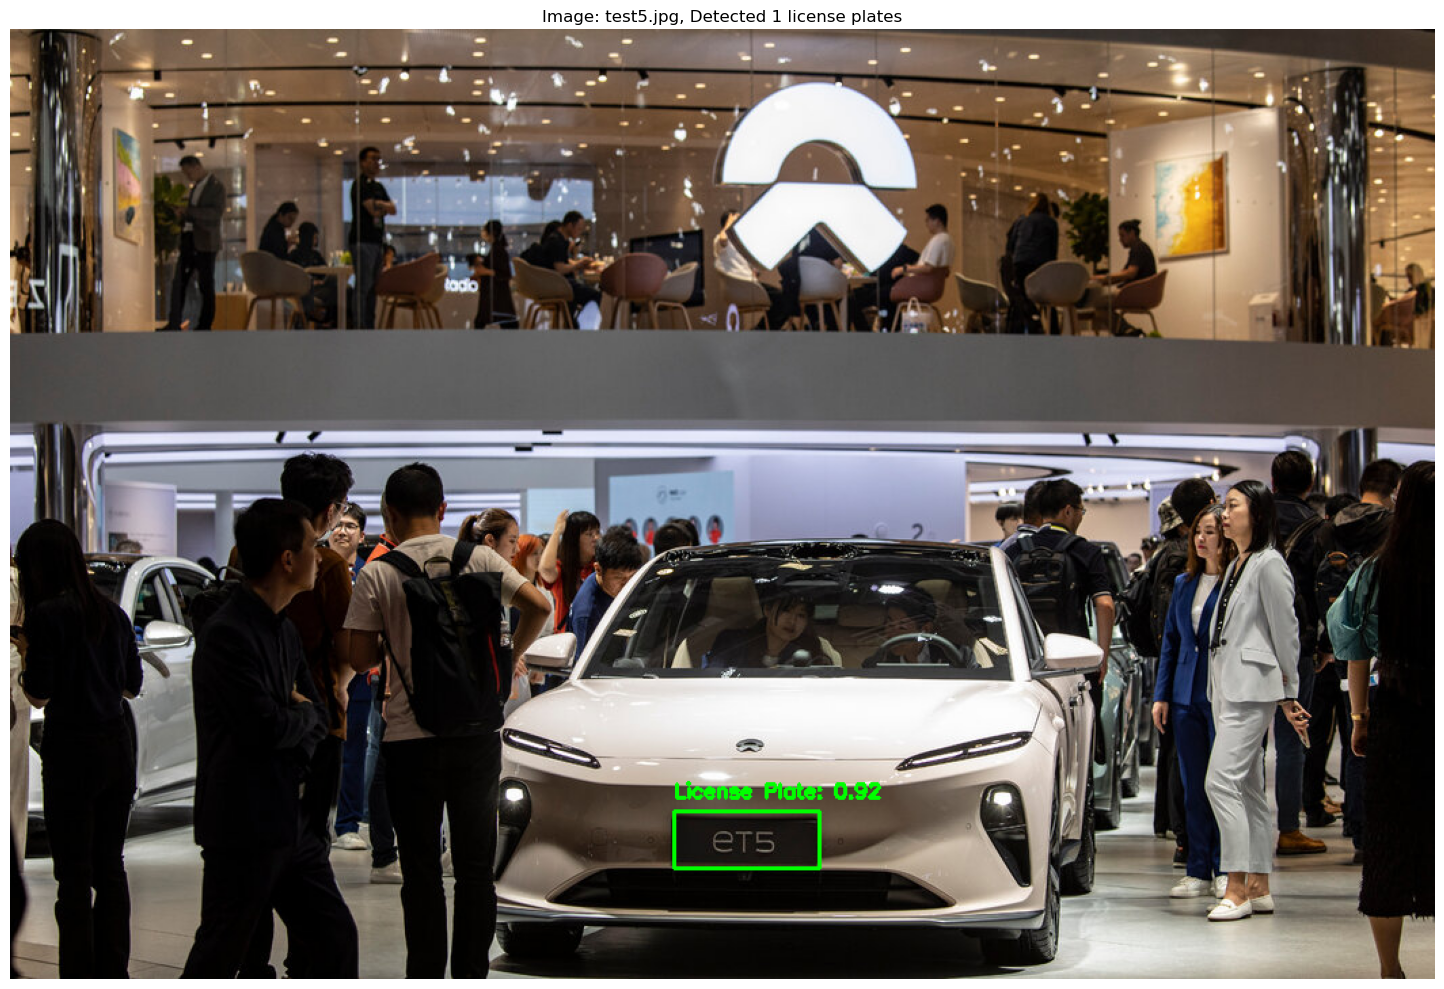

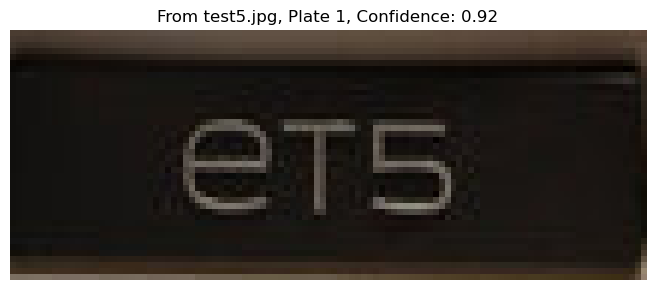

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from detector import LicensePlateDetector
import os
import cv2
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from glob import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

def test_license_plate_detector(detector, model_path=None, image_path=None, 
                               image_dir=None, confidence_threshold=0.8, 
                               save_results=True, output_dir='output_detections'):
    """
    Test license plate detection using trained model
    
    Args:
        detector: LicensePlateDetector instance
        model_path: Model path (.pth file)
        image_path: Single image path (choose one between image_path and image_dir)
        image_dir: Image directory path (choose one between image_path and image_dir)
        confidence_threshold: Confidence threshold
        save_results: Whether to save results
        output_dir: Directory to save results
        
    Returns:
        List of detected license plate information
    """
    # Check parameters
    if image_path is None and image_dir is None:
        raise ValueError("Must provide either image_path or image_dir parameter")
    
    if image_path is not None and image_dir is not None:
        print("Warning: Both image_path and image_dir provided, will prioritize image_path")
    
    # Load model
    if model_path is None:
        model_path = 'license_plate_model.pth'
        print(f"No model path specified, using default path: {model_path}")
    
    device = detector.device
    model = detector.get_model()
    
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Successfully loaded model: {model_path}")
    except Exception as e:
        print(f"Failed to load model: {str(e)}")
        return []
    
    model.to(device)
    model.eval()
    
    # Create output directory
    if save_results:
        os.makedirs(output_dir, exist_ok=True)
        print(f"Results will be saved to: {output_dir}")
    
    # Get list of images to process
    if image_path is not None:
        image_files = [image_path]
    else:
        image_files = glob(os.path.join(image_dir, '*.jpg')) + \
                      glob(os.path.join(image_dir, '*.jpeg')) + \
                      glob(os.path.join(image_dir, '*.png'))
        
        if not image_files:
            print(f"No images found in directory {image_dir}")
            return []
        
        print(f"Found {len(image_files)} images")
    
    # Prepare image transformations
    transform = A.Compose([
        A.Resize(height=512, width=512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])
    
    all_results = []
    
    # Process each image
    for img_file in tqdm(image_files, desc="Processing images"):
        try:
            # Read image
            image = cv2.imread(img_file)
            if image is None:
                print(f"Cannot read image: {img_file}, skipping")
                continue
            
            original_image = image.copy()
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Record original dimensions
            original_height, original_width = image.shape[:2]
            
            # Apply transformations
            transformed = transform(image=image_rgb)
            image_tensor = transformed['image'].unsqueeze(0).to(device)
            
            # Model prediction
            with torch.no_grad():
                prediction = model(image_tensor)
            
            # Process prediction results
            pred_boxes = prediction[0]['boxes'].cpu().numpy()
            pred_scores = prediction[0]['scores'].cpu().numpy()
            
            # Filter high confidence predictions
            mask = pred_scores >= confidence_threshold
            boxes = pred_boxes[mask]
            scores = pred_scores[mask]
            
            result_image = original_image.copy()
            license_plates = []
            
            # Process each detected license plate
            for i, (box, score) in enumerate(zip(boxes, scores)):
                # Convert coordinates to original image size
                x1, y1, x2, y2 = box
                x1 = int(x1 * original_width / 512)
                y1 = int(y1 * original_height / 512)
                x2 = int(x2 * original_width / 512)
                y2 = int(y2 * original_height / 512)
                
                # Ensure coordinates are within image bounds
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(original_width, x2)
                y2 = min(original_height, y2)
                
                # Draw bounding box
                cv2.rectangle(result_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Add label and confidence
                label = f"License Plate: {score:.2f}"
                cv2.putText(result_image, label, (x1, y1 - 10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
                # Extract license plate image
                plate_img = detector.extract_license_plate(original_image, {
                    'xmin': x1, 'ymin': y1, 'xmax': x2, 'ymax': y2
                })
                
                plate_info = {
                    'image_path': img_file,
                    'xmin': x1,
                    'ymin': y1,
                    'xmax': x2,
                    'ymax': y2,
                    'confidence': float(score),
                    'plate_image': plate_img
                }
                
                license_plates.append(plate_info)
            
            # Save results
            if save_results:
                base_name = os.path.splitext(os.path.basename(img_file))[0]
                
                # Save image with bounding boxes
                result_path = os.path.join(output_dir, f"{base_name}_detected.jpg")
                cv2.imwrite(result_path, result_image)
                
                # Save detected license plates
                for i, plate in enumerate(license_plates):
                    if plate['plate_image'] is not None:
                        plate_path = os.path.join(output_dir, f"{base_name}_plate_{i+1}.jpg")
                        cv2.imwrite(plate_path, plate['plate_image'])
                        plate['plate_image_path'] = plate_path
            
            # Print results
            print(f"\nImage: {os.path.basename(img_file)}")
            print(f"Detected {len(license_plates)} license plates")
            
            for i, plate in enumerate(license_plates):
                print(f"Plate {i+1}: Position=({plate['xmin']}, {plate['ymin']}, {plate['xmax']}, {plate['ymax']}), "
                     f"Confidence={plate['confidence']:.2f}")
            
            # Add to total results
            all_results.append({
                'image_path': img_file,
                'license_plates': license_plates,
                'result_image': result_image
            })
            
        except Exception as e:
            print(f"Error processing image {img_file}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    # Return results
    return all_results

def visualize_detection_results(results, num_samples=4, figsize=(15, 10)):
    """
    Visualize detection results
    
    Args:
        results: Return value from test_license_plate_detector function
        num_samples: Number of samples to display
        figsize: Figure size
    """
    if not results:
        print("No detection results to display")
        return
    
    # Limit number of samples
    samples = results[:min(num_samples, len(results))]
    n_samples = len(samples)
    
    fig, axes = plt.subplots(n_samples, 1, figsize=figsize)
    if n_samples == 1:
        axes = [axes]
    
    for i, result in enumerate(samples):
        img = cv2.cvtColor(result['result_image'], cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f"Image: {os.path.basename(result['image_path'])}, "
                         f"Detected {len(result['license_plates'])} license plates")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Show detected license plates
    plates = []
    titles = []
    
    for result in samples:
        for i, plate in enumerate(result['license_plates']):
            if 'plate_image' in plate and plate['plate_image'] is not None:
                plates.append(cv2.cvtColor(plate['plate_image'], cv2.COLOR_BGR2RGB))
                titles.append(f"From {os.path.basename(result['image_path'])}, Plate {i+1}, "
                            f"Confidence: {plate['confidence']:.2f}")
    
    if plates:
        n_plates = len(plates)
        cols = min(4, n_plates)
        rows = (n_plates + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
        if rows * cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        for i in range(len(plates)):
            axes[i].imshow(plates[i])
            axes[i].set_title(titles[i])
            axes[i].axis('off')
        
        # Hide extra subplots
        for i in range(len(plates), len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No license plates detected “o display")


# Usage example
if __name__ == "__main__":
    
    # Initialize detector
    detector = LicensePlateDetector("C:\\Users\\shenz\\Downloads\\archive")
    
    # Method 1: Test single image
    results = test_license_plate_detector(
        detector,
        model_path="license_plate_model.pth",
        image_path="C:/Users/shenz/Desktop/test/test5.jpg",
        confidence_threshold=0.8,
        save_results=True,
        output_dir="detection_results"
    )
    
    # Method 2: Test entire directory
    # results = test_license_plate_detector(
    #     detector,
    #     model_path="license_plate_model.pth",
    #     image_dir="test_images",
    #     confidence_threshold=0.5,
    #     save_results=True,
    #     output_dir="detection_results"
    # )
    
    # Visualize results
    visualize_detection_results(results)